In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import coulomb as cb
    
exp_data = pd.read_csv(f'../data/goshtasbi_et_al_2020/Goshtasbi2020-tn.csv', sep=';', decimal=',')
exp_data['case'] = exp_data[['T_stack', 'rh_ca', 'rh_an', 'st_ca', 'st_an', 'p_ca_out']].sum(axis=1)
case_list = [1,2,3,4,5,6]
exp_data['case'] = exp_data['case'].map(dict(zip(exp_data['case'].unique(),case_list)))

In [2]:
def compute_ui_curve(fuel_cell, case): 
        current_density = np.maximum(1e-4,1e4*exp_data.loc[exp_data.case == case, 'i'].values)
        cathode_conditions = cb.OperatingConditions(
            inlet_temperature = exp_data.loc[exp_data.case == case, 'T_stack'].values,
            inlet_relative_humidity=exp_data.loc[exp_data.case == case, 'rh_ca'].values,
            outlet_pressure=exp_data.loc[exp_data.case == case, 'p_ca_out'].values,
            dry_o2_mole_fraction=0.21,
            dry_h2_mole_fraction=0,
            stoichiometry=np.maximum(1, 0.1e4 / (current_density+1e-4)) *  exp_data.loc[exp_data.case == case, 'st_ca'].values,
        )
        anode_conditions = cb.OperatingConditions(
            inlet_temperature = exp_data.loc[exp_data.case == case, 'T_stack'].values,
            inlet_relative_humidity=exp_data.loc[exp_data.case == case, 'rh_an'].values,
            outlet_pressure=exp_data.loc[exp_data.case == case, 'p_an_out'].values,
            dry_o2_mole_fraction=0,
            dry_h2_mole_fraction=1,
            stoichiometry=np.maximum(1, 0.1e4 / (current_density+1e-4)) * exp_data.loc[exp_data.case == case, 'st_an'].values,
        )

        fuel_cell.set_conditions(exp_data.loc[exp_data.case == case, 'T_stack'].values, 
                                 current_density,cathode_conditions, anode_conditions)

 
        # mea_temperature = fuel_cell.temperature + fuel_cell.dT_ref * (fuel_cell.current_density / 1e4) ** 2
        # fuel_cell.set_mea_temperature(mea_temperature)
        # fuel_cell.calculate_water_transport()
        # fuel_cell.calculate_reactant_concentration_at_cl()
 
        fuel_cell.solve_transport() 
        return fuel_cell.cell_voltage()

In [3]:
def create_fuel_cell(params): 
    fc = cb.FuelCell(
        electrical_resistance=params['r-elec'],
        cell_area = 40e-4, 
        cell_number = 1, 
        ca = cb.FuelCellSide(
            cl=cb.CatalystLayer(
                ecsa=70e3, 
                platinum_loading=0.15e-2, 
                ionomer=cb.CatalystLayerIonomerModel(
                    hydrated_proton_conductivity=6e-6 / 0.3 / params['R-cl-0'], 
                    proton_conductivity_exponent=params['R-cl-exponent']
                ),
                ionomer_to_carbon_ratio=1.3,
                catalyst_platinum_weight_percent=0.4,
                carbon_agglomerate_radius=40e-9,
                thickness=6e-6,
                thermal_conductivity=0.3,
                effective_gas_diffusion_ratio=100000.,
                reaction=cb.ElectrochemicalReaction(
                    reference_exchange_current_density=3e-1,
                    reaction_order=0.7, 
                    activation_energy=67e6, 
                    reference_activity=1.01325e5,
                    reference_temperature=353.15,
                    number_of_electrons=2,
                    charge_transfer_coeff=0.35
                ), 
                
            ),
            gdl=cb.PorousLayer(
                thickness=135e-6,
                effective_gas_diffusion_ratio=params['gdl-diffusion-ratio'],
                thermal_conductivity=0.5,
            ),
            has_mpl=False, 
            ch=cb.GasFlowChannel(
                reactant='o2',
                height=0.04e-2, 
                width=0.1e-2,
                n_parallel=4,
                length=40e-4 / 0.15e-2 / 4,
                transport_resistance_model = cb.ChannelGasResistanceModel(params['A_ch'], params['B_ch'])
            ),
            liq_transport_model=cb.PorousLiquidTransportModel(
                critical_damkholer=params['critical-damkholer'],
                dry_wet_transition_parameter=params['wet-transition'],
                wet_saturation=params['wet-saturation']
            ),
            thermal_contact_resistance=0,
        ),
        an = cb.FuelCellSide(
            cl=cb.CatalystLayer(
                thickness=3e-6, 
                effective_gas_diffusion_ratio=100000.,
                thermal_conductivity=0.3
            ),
            has_mpl=False, 
            gdl=cb.PorousLayer(
                thickness=135e-6,
                effective_gas_diffusion_ratio=params['gdl-diffusion-ratio'],
                thermal_conductivity=0.5,
            ),
            ch=cb.GasFlowChannel(
                reactant='h2',
                height=0.04e-2, 
                width=0.1e-2,
                n_parallel=4,
                length=40e-4 / 0.15e-2 / 4,
                transport_resistance_model = cb.ChannelGasResistanceModel(params['A_ch'], params['B_ch'])
            ),
            thermal_contact_resistance=0
        ),
        membrane = cb.Membrane(
            equivalent_weight=1000,
            density=1900, 
            dry_thickness=params['memb-thickness'],
            water_balance_model=cb.MembraneWaterBalanceModel(absorption_coefficient=params['memb-abs-constant'])
        )
    )
    # fc.dT_ref = params['gdl-deltaT-ref']
    # for side in (fc.ca, fc.an):
    #     side.ch.transport_resistance_model.B_ch = fc.cell_area / (side.ch.length /side.ch.half_width * side.ch.total_flow_section)/ 2
    return fc

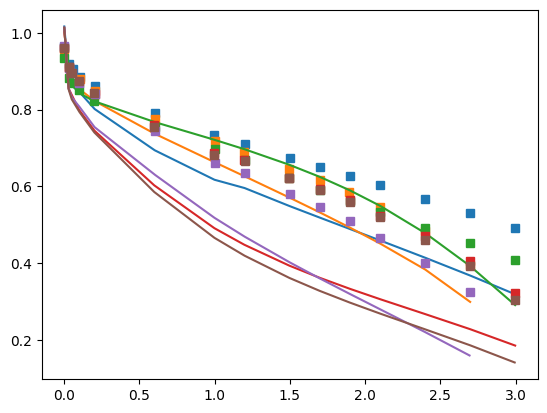

In [4]:
train_case_list = [4,5,6]
test_case_list = [1,4,6]
def h(params, case_list=train_case_list): 
    fuel_cell = create_fuel_cell(params)
    return np.concatenate(
         [compute_ui_curve(fuel_cell, case) for case in case_list]
    )

exp_voltage_list = np.concatenate(
         [exp_data.loc[exp_data.case == case, 'U'] for case in train_case_list]
    )

model = cb.ParameterEstimationSteadyState(h, {'r-elec': 54e-7, 
                                              'A_ch': 1.0, 
                                              'B_ch': 1.0,
                                              'gdl-diffusion-ratio': 0.5,
                                              'memb-abs-constant': 1e-06, 
                                              'wet-saturation': 0.2, 
                                              'R-cl-0': 1e-6,
                                              'R-cl-exponent': 4.17,
                                              'critical-damkholer': 1.00, 
                                              'wet-transition': 122,
                                              'memb-thickness': 20e-6})
fuel_cell = create_fuel_cell(model.p)
for k, case in enumerate(case_list): 
    U_sim = compute_ui_curve(fuel_cell, case)
    plt.figure(1)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, U_sim, 'C{}-'.format(k))
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, exp_data.loc[exp_data.case == case, 'U'].values, 'C{}s'.format(k))


In [5]:
model.set_unknown_params(
        [
        
        #('memb-thickness', (5e-6, 30e-6), True, '$t_m$'), 
        ('A_ch', (0,10), True, '$A_{ch}$'), 
        ('B_ch', (0,10), True, '$B_{ch}$'), 

        ('r-elec', (5e-7,80e-7), True, '$R_{elec}$'),
        ('wet-saturation', (0.,0.6), True, '$R_{wet}$'),
        ('wet-transition', (80,200), True, r'$\alpha_{wet}$'),
        ('critical-damkholer', (0.8,1.5), True, '$Da_{w,cr}$'),
        
        ('R-cl-exponent', (0, 5), True, '$m_{R_{cl}}$'),
        ('R-cl-0', (1e-7, 50e-7), True, '$R_{cl,0}$'),
        ('gdl-diffusion-ratio', (.5,1), True, '$D_{eff}/D$'),
        #('E-act-ca', (50e3, 100e3), True, '$E_{act, ca}$'),
        #('omega-PtO', (1e3, 10e3), True, '$\omega_{PtO}$'),
        #('memb-water-diff', (1e-10, 40e-10), True, '$D_{\lambda}$'),
        ('memb-abs-constant', (1e-6, 1e-3), True, '$k_{abs}$'),
        ]
    )


In [6]:

cosPhi_med_ij, norm_s_i, S_med, S_std, S_med_i, S_std_i, S_n, n_valid = model.compute_global_sensitivity(t=0, m=8,  
                                                                                                         check_samples=True,
                                                                                                         y_exp=exp_voltage_list, 
                                                                                                         res_limit=0.02)


Number of valid samples: 10


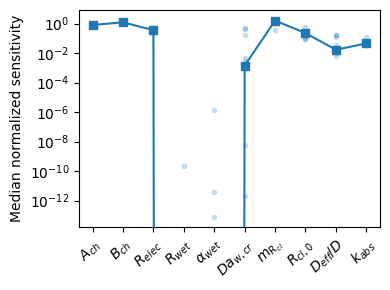

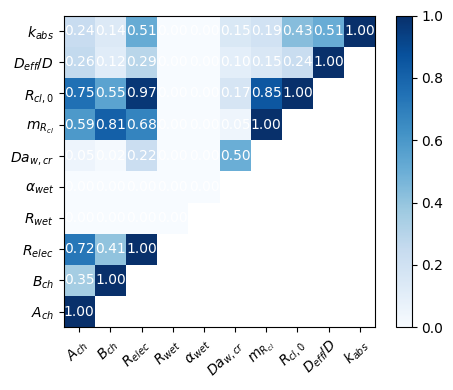

In [7]:
print('Number of valid samples: {:d}'.format(n_valid))
fig1, ax1 = model.plot_global_sensitivity(xlabel_angle=45) 
fig2, ax2 = model.plot_colinearity_map(xlabel_angle=45, cmap='Blues',figsize=(5,4))

plt.show()

In [8]:
sol, p_est = model.estimate(exp_voltage_list, t=0, print_iterations=True, popsize=20, ftol=1e-5)
model.p.update({param: v for param, v in zip(model.p_i_name, p_est)})

differential_evolution step 1: f(x)= 0.0005888379155053073
------------------------------
[1.92401617e+00 4.91213719e-01 6.55928073e-06 3.57292155e-01
 1.51873421e+02 1.49474899e+00 8.20393473e-01 1.00354657e-06
 7.93613218e-01 7.09984487e-04]
('A_ch', (0, 10), True, '$A_{ch}$') 1.92e+00
('B_ch', (0, 10), True, '$B_{ch}$') 4.91e-01
('r-elec', (5e-07, 8e-06), True, '$R_{elec}$') 6.56e-06
('wet-saturation', (0.0, 0.6), True, '$R_{wet}$') 3.57e-01
('wet-transition', (80, 200), True, '$\\alpha_{wet}$') 1.52e+02
('critical-damkholer', (0.8, 1.5), True, '$Da_{w,cr}$') 1.49e+00
('R-cl-exponent', (0, 5), True, '$m_{R_{cl}}$') 8.20e-01
('R-cl-0', (1e-07, 5e-06), True, '$R_{cl,0}$') 1.00e-06
('gdl-diffusion-ratio', (0.5, 1), True, '$D_{eff}/D$') 7.94e-01
('memb-abs-constant', (1e-06, 0.001), True, '$k_{abs}$') 7.10e-04
------------------------------
differential_evolution step 2: f(x)= 0.0005510332596402848
------------------------------
[2.55963495e+00 1.95762641e-01 6.05908521e-06 1.44152757e-

KeyboardInterrupt: 

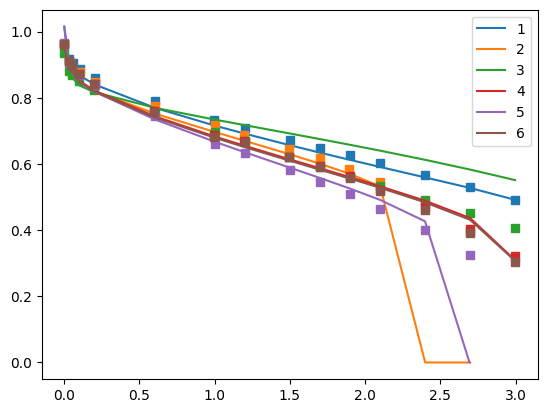

In [ ]:
fuel_cell = create_fuel_cell(model.p)
for k, case in enumerate(case_list): 
    U_sim = compute_ui_curve(fuel_cell, case)
    plt.figure(1)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, U_sim, 'C{}-'.format(k), label=case)
    plt.plot(exp_data.loc[exp_data.case == case, 'i'].values, exp_data.loc[exp_data.case == case, 'U'].values, 'C{}s'.format(k))
    plt.legend()
    # plt.figure(2)
    # plt.plot(fuel_cell.current_density, fuel_cell.mea_temperature_increase)
    # plt.figure(3)
    # plt.plot(fuel_cell.current_density, fuel_cell.membrane.water_content)
    # plt.plot(fuel_cell.current_density, fuel_cell.ca.equiv_water_content, 'C{}s'.format(k))
    # plt.plot(fuel_cell.current_density, fuel_cell.an.equiv_water_content, 'C{}o'.format(k))
    # #plt.plot(fuel_cell.current_density, fuel_cell.ca.a, 'C{}-'.format(k))
    # plt.plot(fuel_cell.current_density, fuel_cell.ca.membrane_surface_water_content, 'C{}--'.format(k))
    # plt.plot(fuel_cell.current_density, fuel_cell.an.membrane_surface_water_content, 'C{}-.'.format(k))
    # plt.figure(4)
    # plt.plot(fuel_cell.current_density, fuel_cell.ca.cl.proton_resistance)
    # print(fuel_cell.ca.cl.ionomer_vol_fraction)
    # print(fuel_cell.ca.cl.ionomer_film_thickness)
    # print(fuel_cell.ca.cl.calculate_ionomer_sheet_proton_resistance(1,14,353.15))
    # plt.plot(fuel_cell.current_density, fuel_cell.membrane.pe)
    # plt.plot(fuel_cell.current_density, fuel_cell.membrane.bi, 'C{}--'.format(k))
    # plt.plot(fuel_cell.current_density, fuel_cell.ca.K, 'C{}.-'.format(k))
    # print(fuel_cell.membrane.dry_concentration)